In [51]:
import numpy as np
np.set_printoptions(precision=3, suppress=True)
X = np.array([
    [1.0, 0.0, 1.0, 0.0],  # token 1
    [0.0, 2.0, 0.0, 1.0],  # token 2
    [1.0, 1.0, 0.0, 2.0],  # token 3
    [0.0, 1.0, 2.0, 1.0],  # token 4
])
print("X:")
print(X)
print("Shape:", X.shape)

X2 = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])
print("\nX2:")
print(X2)
print("Shape of X2:", X2.shape)

X:
[[1. 0. 1. 0.]
 [0. 2. 0. 1.]
 [1. 1. 0. 2.]
 [0. 1. 2. 1.]]
Shape: (4, 4)

X2:
[[1. 0.]
 [0. 1.]
 [1. 1.]]
Shape of X2: (3, 2)


In [52]:
d_model = X.shape[1]
d_k = 4
np.random.seed(42)

WQ = np.random.randn(d_model, d_k)
WK = np.random.randn(d_model, d_k)
WV = np.random.randn(d_model, d_k)

W_Q = np.eye(d_model)
W_K = np.eye(d_model)
W_V = np.eye(d_model)

print("\nW_Q:")
print(W_Q)

print("\nW_K:")
print(W_K)

print("\nW_V:")
print(W_V)

Q = X @ WQ
K = X @ WK
V = X @ WV

print("\nQ:")
print(Q)

print("\nK:")
print(K)

print("\nV:")
print(V)

Q2 = X @ W_Q
K2 = X @ W_K
V2 = X @ W_V

print("\nQ2:")
print(Q2)

print("\nK2:")
print(K2)

print("\nV2:")
print(V2)


W_Q:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

W_K:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

W_V:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Q:
[[ 0.02723977  0.40429574  0.18427085  1.0573001 ]
 [-0.22634448 -2.38155416  1.4335078   0.97258193]
 [ 0.74648532 -4.19896175 -1.22293431  1.16588953]
 [-0.93113988 -1.06229711 -1.0725404  -0.72631231]]

K:
[[-1.55721384  0.42516992 -2.05901765 -1.03660568]
 [ 2.33065885 -0.74324635 -0.4666502  -0.99721819]
 [-0.74845973 -0.49491647 -2.0439091   0.86750448]
 [-0.22375537 -0.29562487 -2.83616556  1.17892603]]

V:
[[ 0.72496936 -0.88634265  0.70689663 -1.52194735]
 [-1.0607948  -4.63918446 -3.11701087  1.4508447 ]
 [-2.76167761 -4.45706947 -1.42691868  1.09026204]
 [ 0.20727476 -2.33677777 -2.02012138  0.65177607]]

Q2:
[[1. 0. 1. 0.]
 [0. 2. 0. 1.]
 [1. 1. 0. 2.]
 [0. 1. 2. 1.]]

K2:
[[1. 0. 1. 0.]
 [0. 2. 0. 1.]
 [1. 1. 0. 2.]
 [0. 1. 2. 1.]]

V2:
[[1. 0. 1. 0.]
 [0. 2. 0. 1.]
 [1. 

In [53]:
scores = Q @ K.T
print("\nRaw attention scores:")
print(scores)

scores2 = Q2 @ K2.T
print("\nRaw attention scores2:")
print(scores2)


Raw attention scores:
[[-1.34594397 -1.37735365  0.32009923  0.59824107]
 [-4.61990026 -0.39627342 -0.73816035 -2.16437086]
 [-1.63823389  4.26870192  5.03040206  5.91722912]
 [ 3.95960621 -0.1558279   2.78476494  2.70802266]]

Raw attention scores2:
[[2. 0. 1. 2.]
 [0. 5. 4. 3.]
 [1. 4. 6. 3.]
 [2. 3. 3. 6.]]


In [54]:
scores = scores / np.sqrt(d_k)
print("\nScaled attention scores:")
print(scores)


Scaled attention scores:
[[-0.67297199 -0.68867683  0.16004962  0.29912054]
 [-2.30995013 -0.19813671 -0.36908017 -1.08218543]
 [-0.81911695  2.13435096  2.51520103  2.95861456]
 [ 1.97980311 -0.07791395  1.39238247  1.35401133]]


In [55]:
mask = np.triu(
    np.ones_like(scores),
    k =1 
)
scores = np.where(
    mask == 1,
    -np.inf,
    scores
)
print("Masked scores:")
print(scores)

Masked scores:
[[-0.67297199        -inf        -inf        -inf]
 [-2.30995013 -0.19813671        -inf        -inf]
 [-0.81911695  2.13435096  2.51520103        -inf]
 [ 1.97980311 -0.07791395  1.39238247  1.35401133]]


In [56]:
def softmax(x):
    x = x - np.max(x,axis=-1,keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(
        exp_x,
        axis=-1,
        keepdims=True
    )
    
attention_weights = softmax(scores)
tokens = ["The", "cat", "eats", "fish"]
print("Attention Weights:")
print("           " + "  ".join(f"{t:>8}" for t in tokens))

for token, weights in zip(tokens, attention_weights):
    print(
        f"{token:>8}    " +
        "  ".join(f"{w:8.3f}" for w in weights)
    )

token_index = 2

print(
    f"\nWhat does '{tokens[token_index]}' attend to?"
)

for token, weight in zip(
    tokens,
    attention_weights[token_index]
):
    print(f"{token:>8}: {weight:.3f}")

Attention Weights:
                The       cat      eats      fish
     The       1.000     0.000     0.000     0.000
     cat       0.108     0.892     0.000     0.000
    eats       0.021     0.398     0.582     0.000
    fish       0.451     0.058     0.251     0.241

What does 'eats' attend to?
     The: 0.021
     cat: 0.398
    eats: 0.582
    fish: 0.000


In [57]:
output = attention_weights @ V
print("Attention ouput:")
print(output)

Attention ouput:
[[ 0.72496936 -0.88634265  0.70689663 -1.52194735]
 [-0.86801458 -4.23405051 -2.7042051   1.12992017]
 [-2.01327713 -4.45542824 -2.05449904  1.17943598]
 [-0.37618673 -2.34672102 -0.70536772 -0.1722419 ]]


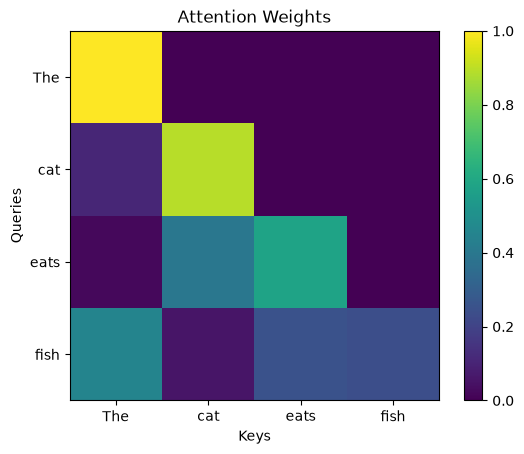

In [58]:
import matplotlib.pyplot as plt
plt.imshow(attention_weights)
plt.xticks(
    range(len(tokens)),
    tokens
)
plt.yticks(
    range(len(tokens)),
    tokens
)
plt.xlabel("Keys")
plt.ylabel("Queries")
plt.title("Attention Weights")

plt.colorbar()
plt.show()